In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("HousePricePrediction.csv")
df.head(20)

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0
5,5,50,RL,14115,Inside,1Fam,5,1993,1995,VinylSd,0.0,796.0,143000.0
6,6,20,RL,10084,Inside,1Fam,5,2004,2005,VinylSd,0.0,1686.0,307000.0
7,7,60,RL,10382,Corner,1Fam,6,1973,1973,HdBoard,32.0,1107.0,200000.0
8,8,50,RM,6120,Inside,1Fam,5,1931,1950,BrkFace,0.0,952.0,129900.0
9,9,190,RL,7420,Corner,2fmCon,6,1939,1950,MetalSd,0.0,991.0,118000.0


In [3]:
df.isnull().any()

Id              False
MSSubClass      False
MSZoning         True
LotArea         False
LotConfig       False
BldgType        False
OverallCond     False
YearBuilt       False
YearRemodAdd    False
Exterior1st      True
BsmtFinSF2       True
TotalBsmtSF      True
SalePrice        True
dtype: bool

In [4]:
from sklearn.impute import SimpleImputer
imp_median = SimpleImputer(strategy="median")
df[["BsmtFinSF2"]] = imp_median.fit_transform(df[["BsmtFinSF2"]])
df[["TotalBsmtSF"]] = imp_median.fit_transform(df[["TotalBsmtSF"]])
df[["SalePrice"]] = imp_median.fit_transform(df[["SalePrice"]])
imp_freq = SimpleImputer(strategy="most_frequent")
df[["MSZoning"]]= imp_freq.fit_transform(df[["MSZoning"]])
df[["Exterior1st"]]= imp_freq.fit_transform(df[["Exterior1st"]])

In [5]:
df.head()
df.isnull().any()

Id              False
MSSubClass      False
MSZoning        False
LotArea         False
LotConfig       False
BldgType        False
OverallCond     False
YearBuilt       False
YearRemodAdd    False
Exterior1st     False
BsmtFinSF2      False
TotalBsmtSF     False
SalePrice       False
dtype: bool

In [6]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["MSZoning"] = le.fit_transform(df["MSZoning"])
df["LotConfig"] = le.fit_transform(df["LotConfig"])
df["BldgType"] = le.fit_transform(df["BldgType"])
df["Exterior1st"] = le.fit_transform(df["Exterior1st"])

In [7]:
df.head()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,3,8450,4,0,5,2003,2003,12,0.0,856.0,208500.0
1,1,20,3,9600,2,0,8,1976,1976,8,0.0,1262.0,181500.0
2,2,60,3,11250,4,0,5,2001,2002,12,0.0,920.0,223500.0
3,3,70,3,9550,0,0,5,1915,1970,13,0.0,756.0,140000.0
4,4,60,3,14260,2,0,5,2000,2000,12,0.0,1145.0,250000.0


In [8]:
features =["MSSubClass","MSZoning","LotArea","LotConfig","BldgType","OverallCond","YearBuilt","YearRemodAdd","Exterior1st","BsmtFinSF2","TotalBsmtSF"]
target=["SalePrice"]

In [9]:
x= df[features]
y= df[target]

In [10]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [11]:
from sklearn.linear_model import LinearRegression

In [16]:
model = LinearRegression()
model.fit(x_train,y_train)
ytrain_pred= model.predict(x_train)
y_pred = model.predict(x_test)

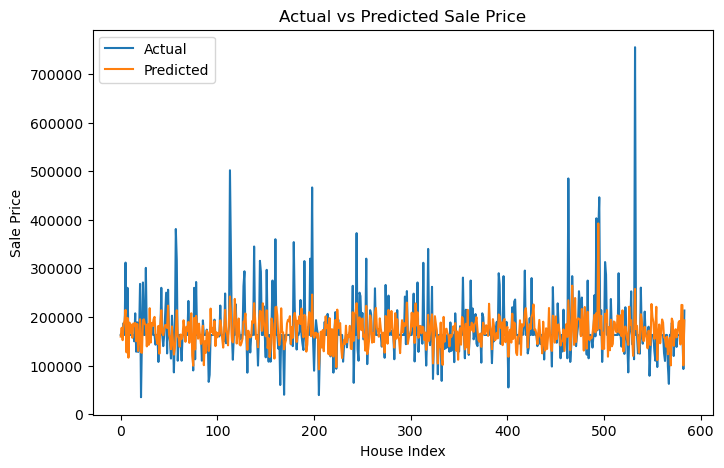

In [13]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))

plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")

plt.xlabel("House Index")
plt.ylabel("Sale Price")
plt.title("Actual vs Predicted Sale Price")

plt.legend()

plt.show()

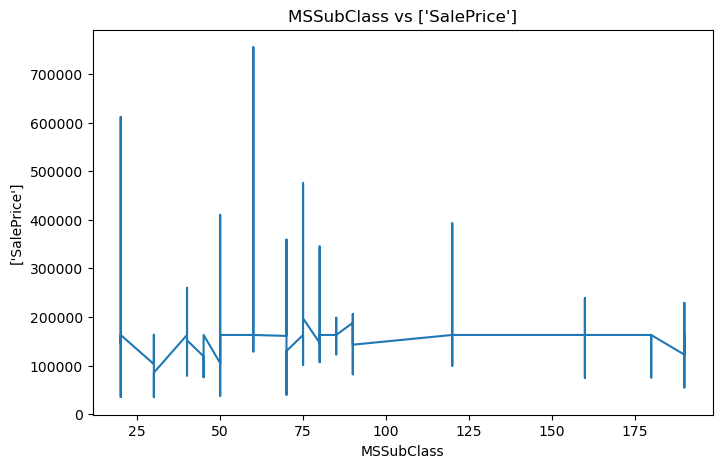

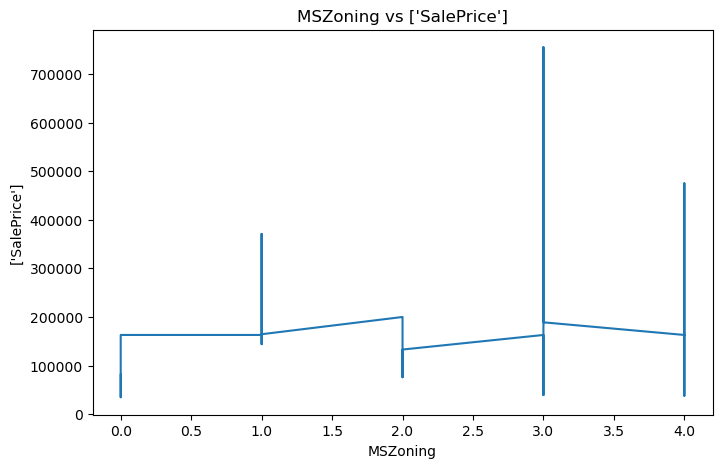

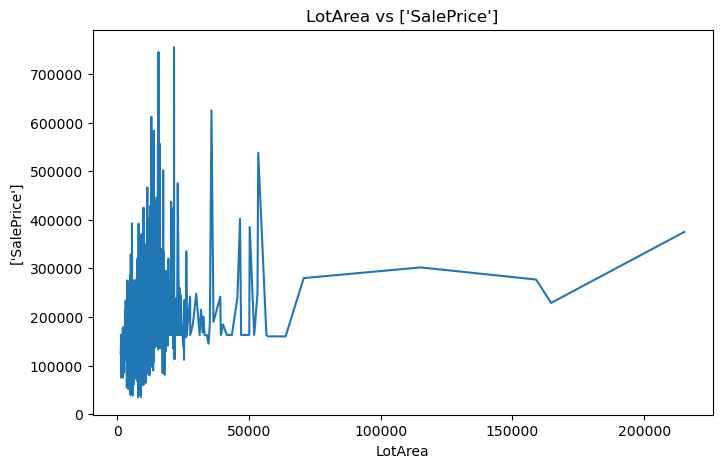

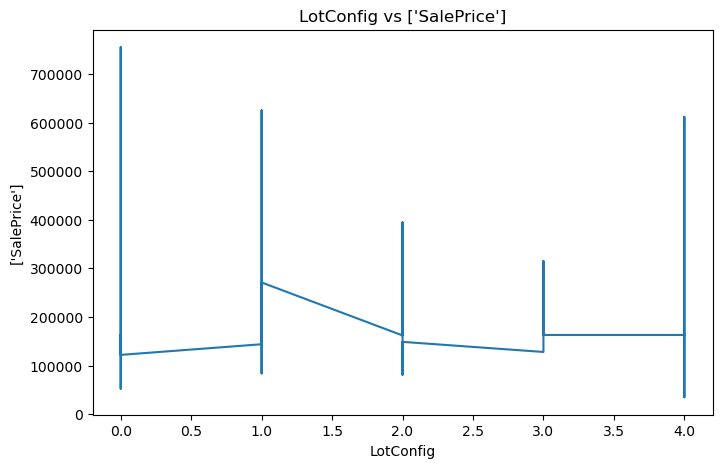

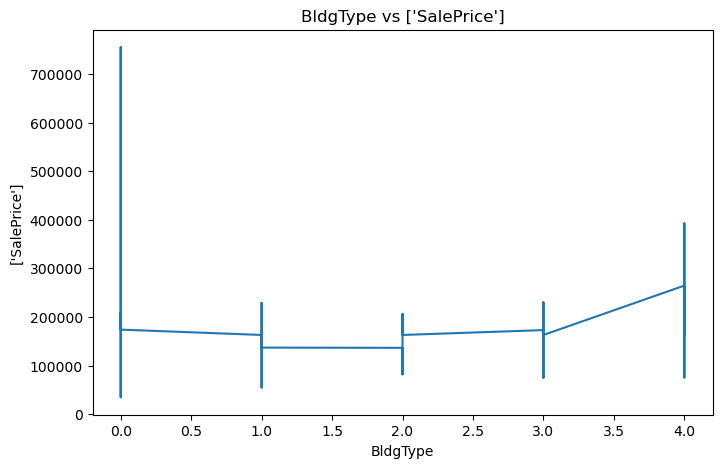

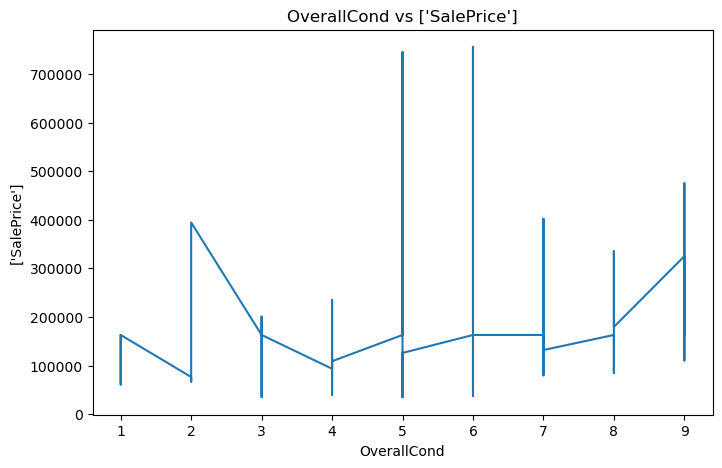

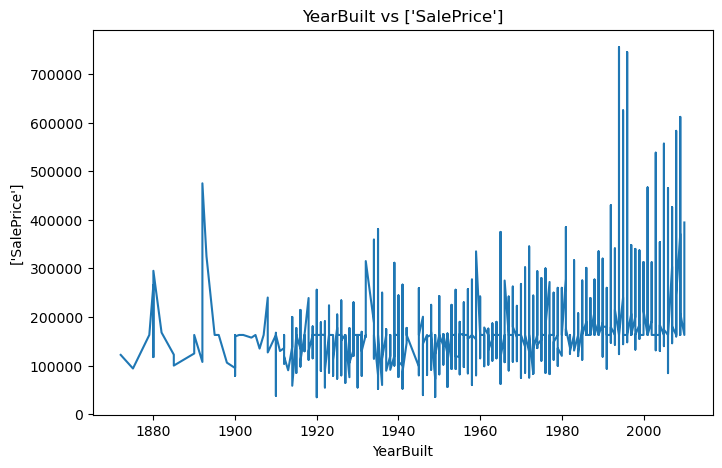

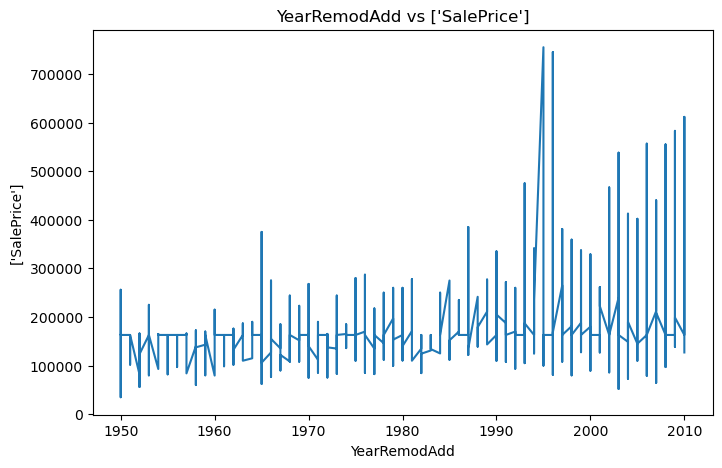

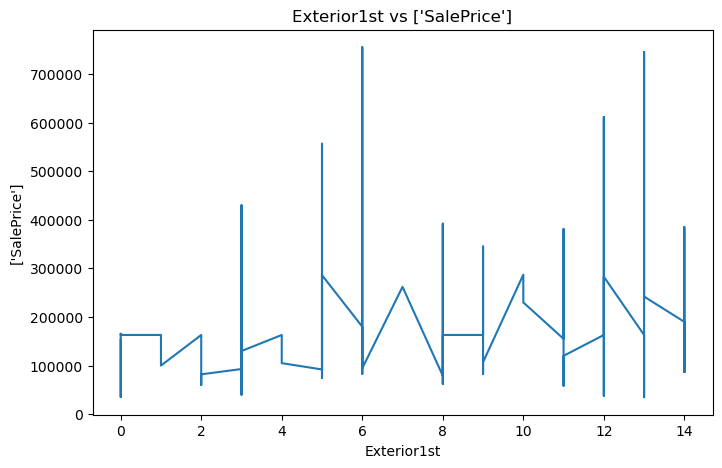

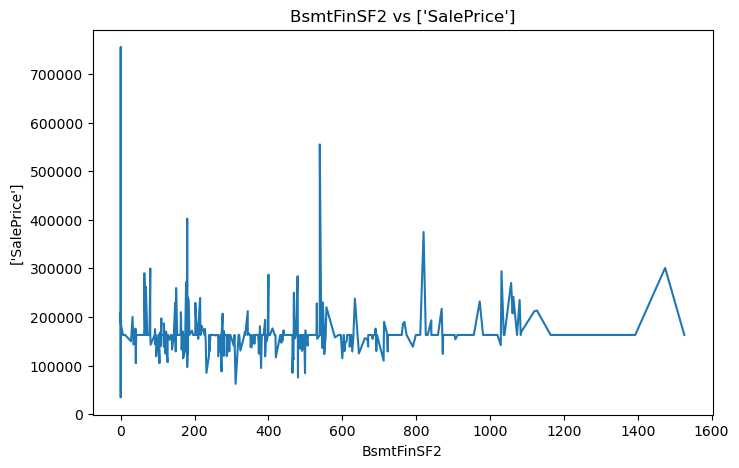

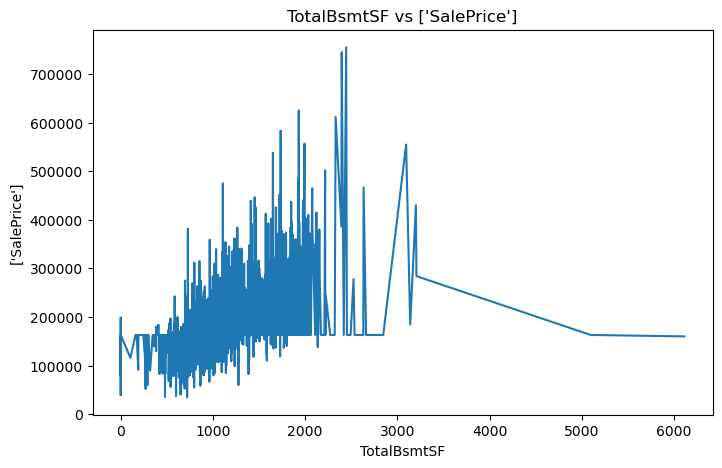

In [14]:
for feature in features:
    
    sorted_df = df.sort_values(by=feature)

    plt.figure(figsize=(8,5))

    plt.plot(
        sorted_df[feature],
        sorted_df[target]
    )

    plt.xlabel(feature)
    plt.ylabel(target)
    plt.title(f"{feature} vs {target}")

    plt.show()

In [19]:
from sklearn.metrics import mean_squared_error

mse_test = mean_squared_error(y_test, y_pred)
mse_train = mean_squared_error(y_train,ytrain_pred)
print("MSE train:", mse_train)
print("MSE test:", mse_test)


MSE train: 2250545799.5286727
MSE test: 2454418974.732637
